In [ ]:
import pandas as pd
import numpy as np
xlsx_path = "/content/Mice_protein_expression_dataset.xlsx"
data_set = pd.read_excel(xlsx_path, sheet_name="Hoja1")
feature_names = data_set.columns.tolist()
# print(feature_names)
print(data_set.isnull().sum())
columns_to_impute = feature_names[1:len(feature_names)-4]
print(len(columns_to_impute))
from sklearn.impute import SimpleImputer
import numpy as np

# impute = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=0)
# impute.fit(data_set[columns_to_impute])
# data_set[columns_to_impute] = impute.transform(data_set[columns_to_impute])
impute = SimpleImputer(missing_values= np.nan, strategy = 'mean')
impute.fit(data_set[columns_to_impute])
data_set[columns_to_impute]=impute.transform(data_set[columns_to_impute])

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_set[columns_to_impute] = scaler.fit_transform(data_set[columns_to_impute])
# data_set.isnull().sum()

MouseID      0
DYRK1A_N     3
ITSN1_N      3
BDNF_N       3
NR1_N        3
            ..
CaNA_N       0
Genotype     0
Treatment    0
Behavior     0
class        0
Length: 82, dtype: int64
77


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoding = LabelEncoder()
features = ['Genotype', 'Treatment', 'Behavior' ]
data_set['Genotype']= encoding.fit_transform(data_set['Genotype'])
data_set['Treatment']= encoding.fit_transform(data_set['Treatment'])
data_set['Behavior']= encoding.fit_transform(data_set['Behavior'])

In [ ]:


data_set['class'] = encoding.fit_transform(data_set['class'])
print("Encoded classes:", encoding.classes_)
print(data_set[['class']])

Encoded classes: ['c-CS-m' 'c-CS-s' 'c-SC-m' 'c-SC-s' 't-CS-m' 't-CS-s' 't-SC-m' 't-SC-s']
      class
0         0
1         0
2         0
3         0
4         0
...     ...
1075      7
1076      7
1077      7
1078      7
1079      7

[1080 rows x 1 columns]


In [ ]:
features = data_set.iloc[:, 1:-4]
target = data_set.iloc[:, -1]
print((features))
print(target)

      DYRK1A_N   ITSN1_N    BDNF_N     NR1_N    NR2A_N    pAKT_N   pBRAF_N  \
0     0.151122  0.212885  0.824638  0.612119  0.630482  0.327006  0.448666   
1     0.155750  0.188226  0.776455  0.601070  0.585247  0.311887  0.429899   
2     0.153459  0.205696  0.793572  0.558911  0.575910  0.306369  0.441381   
3     0.125169  0.157688  0.637326  0.468152  0.480646  0.335530  0.444307   
4     0.122146  0.157838  0.637787  0.426467  0.441977  0.314976  0.433100   
...        ...       ...       ...       ...       ...       ...       ...   
1075  0.046197  0.092577  0.365672  0.313684  0.127872  0.312096  0.423753   
1076  0.053509  0.097062  0.357235  0.342243  0.157739  0.395191  0.468154   
1077  0.035163  0.063556  0.311370  0.165795  0.071655  0.330863  0.384915   
1078  0.032018  0.071071  0.337173  0.224787  0.095856  0.306129  0.433086   
1079  0.066342  0.091503  0.370133  0.313976  0.127028  0.394619  0.504969   

      pCAMKII_N   pCREB_N    pELK_N  ...     SHH_N     BAD_N   

Shape: (1080, 82)

Dtypes:
 MouseID       object
DYRK1A_N     float64
ITSN1_N      float64
BDNF_N       float64
NR1_N        float64
NR2A_N       float64
pAKT_N       float64
pBRAF_N      float64
pCAMKII_N    float64
pCREB_N      float64
dtype: object

Missing values (top 10):
 MouseID      0
DYRK1A_N     0
ITSN1_N      0
BDNF_N       0
NR1_N        0
NR2A_N       0
pAKT_N       0
pBRAF_N      0
pCAMKII_N    0
pCREB_N      0
dtype: int64


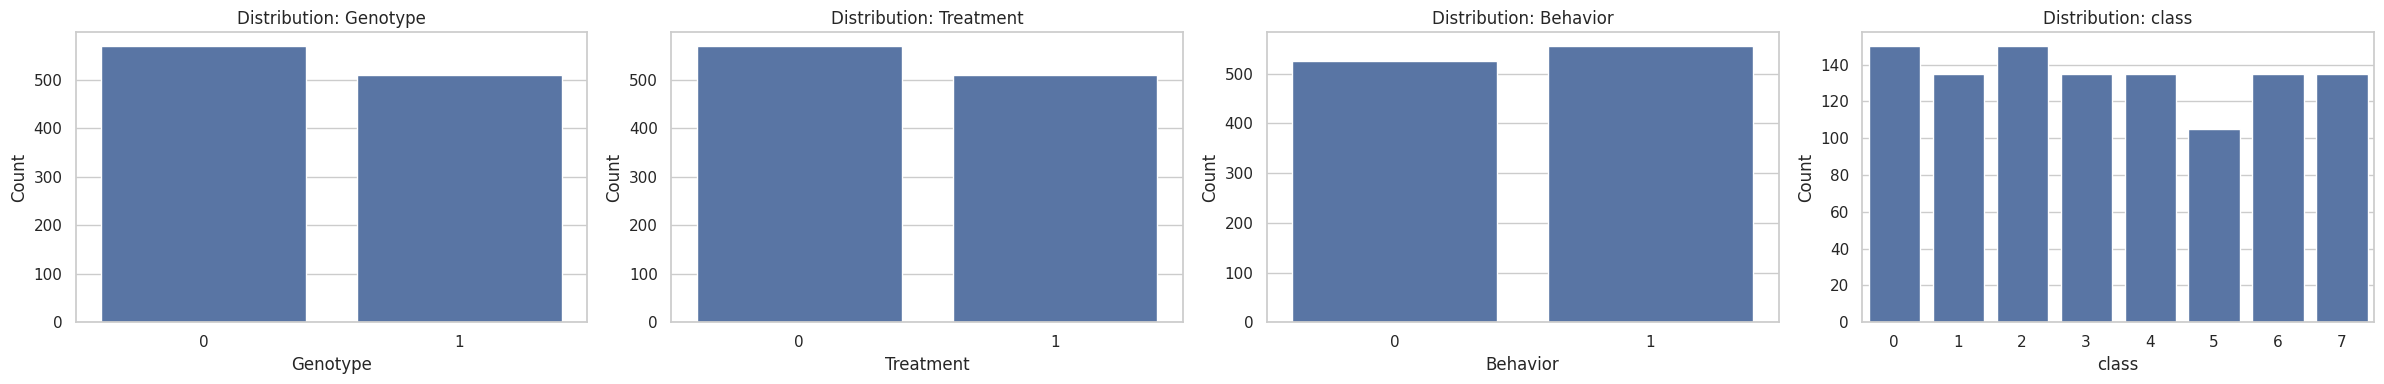

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

# ---------- 0) Summary ----------
print("Shape:", data_set.shape)
print("\nDtypes:\n", data_set.dtypes.head(10))
print("\nMissing values (top 10):\n", data_set.isnull().sum().sort_values(ascending=False).head(10))

# Identify metadata if present
meta_cols = [c for c in ["Genotype", "Treatment", "Behavior", "class"] if c in data_set.columns]
protein_cols = [c for c in columns_to_impute if c in data_set.columns]

# ---------- 1) Distributions of labels ----------
fig, axes = plt.subplots(1, len(meta_cols), figsize=(6*max(1,len(meta_cols)), 4))
if len(meta_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, meta_cols):
    sns.countplot(x=data_set[col], ax=ax)
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count")
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize
x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)

n_classes = len(np.unique(y_train))

def evaluate_classifier(name, model):
    model.fit(x_train, y_train)
    preds = model.predict(x_test)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_test, preds, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_test, preds)

    auc = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(x_test)
        y_test_bin = label_binarize(y_test, classes=range(n_classes))
        auc = roc_auc_score(y_test_bin, proba, multi_class='ovr')

    print(f"\n=== {name} ===")
    print("Accuracy :", f"{acc:.4f}")
    print("Precision:", f"{prec:.4f}")
    print("Recall   :", f"{rec:.4f}")
    print("F1-score :", f"{f1:.4f}")
    if auc is not None:
        print("AUC      :", f"{auc:.4f}")
    print("Confusion Matrix:\n", cm)

    return acc, prec, rec, f1, cm, auc


In [ ]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, r2_score, mean_squared_error
)

import matplotlib.pyplot as plt
import seaborn as sns


=== Logistic Regression ===
Accuracy : 0.9290
Precision: 0.9309
Recall   : 0.9290
F1-score : 0.9292
AUC      : 0.9961
Confusion Matrix:
 [[42  3  0  0  2  0  0  0]
 [ 4 43  0  0  1  1  0  0]
 [ 0  0 42  0  0  0  0  0]
 [ 0  0  0 40  0  0  0  4]
 [ 2  1  0  0 27  1  0  0]
 [ 1  0  0  0  2 30  0  0]
 [ 0  0  1  0  0  0 37  0]
 [ 0  0  0  0  0  0  0 40]]

=== K-Nearest Neighbors (k=7) ===
Accuracy : 0.9444
Precision: 0.9500
Recall   : 0.9444
F1-score : 0.9438
AUC      : 0.9987
Confusion Matrix:
 [[47  0  0  0  0  0  0  0]
 [ 4 44  0  0  1  0  0  0]
 [ 0  0 41  1  0  0  0  0]
 [ 0  0  0 44  0  0  0  0]
 [ 0  0  0  0 30  0  0  1]
 [ 2  1  0  0  5 25  0  0]
 [ 0  0  0  0  0  0 35  3]
 [ 0  0  0  0  0  0  0 40]]

=== Random Forests ===
Accuracy : 0.9815
Precision: 0.9845
Recall   : 0.9815
F1-score : 0.9814
AUC      : 0.9996
Confusion Matrix:
 [[47  0  0  0  0  0  0  0]
 [ 0 49  0  0  0  0  0  0]
 [ 0  0 42  0  0  0  0  0]
 [ 0  0  0 44  0  0  0  0]
 [ 0  0  0  0 31  0  0  0]
 [ 0  0  0  0  6

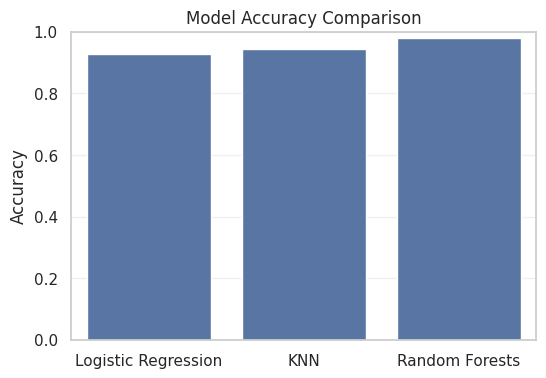

In [ ]:
log_model = LogisticRegression(max_iter=500, solver="lbfgs", n_jobs=-1)
logistic_accuracy, logistic_precision, logistic_recall, logistic_f1, logistic_cm, logistic_auc = \
    evaluate_classifier("Logistic Regression", log_model)


knn_model = KNeighborsClassifier(n_neighbors=7)
knn_accuracy, knn_precision, knn_recall, knn_f1, knn_cm, knn_auc = \
    evaluate_classifier("K-Nearest Neighbors (k=7)", knn_model)


rf_model = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
rf_accuracy, rf_precision, rf_recall, rf_f1, rf_cm, rf_auc = \
    evaluate_classifier("Random Forests", rf_model)

models = ["Logistic Regression", "KNN", "Random Forests"]
accuracies = [logistic_accuracy, knn_accuracy, rf_accuracy]
plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracies)
plt.ylabel("Accuracy"); plt.title("Model Accuracy Comparison")
plt.ylim(0,1); plt.grid(True, axis='y', alpha=0.3)
plt.show()


=== Logistic Regression ===
Accuracy : 0.9290
Precision: 0.9309
Recall   : 0.9290
F1-score : 0.9292
AUC      : 0.9961
Confusion Matrix:
 [[42  3  0  0  2  0  0  0]
 [ 4 43  0  0  1  1  0  0]
 [ 0  0 42  0  0  0  0  0]
 [ 0  0  0 40  0  0  0  4]
 [ 2  1  0  0 27  1  0  0]
 [ 1  0  0  0  2 30  0  0]
 [ 0  0  1  0  0  0 37  0]
 [ 0  0  0  0  0  0  0 40]]

=== K-Nearest Neighbors (k=7) ===
Accuracy : 0.9444
Precision: 0.9500
Recall   : 0.9444
F1-score : 0.9438
AUC      : 0.9987
Confusion Matrix:
 [[47  0  0  0  0  0  0  0]
 [ 4 44  0  0  1  0  0  0]
 [ 0  0 41  1  0  0  0  0]
 [ 0  0  0 44  0  0  0  0]
 [ 0  0  0  0 30  0  0  1]
 [ 2  1  0  0  5 25  0  0]
 [ 0  0  0  0  0  0 35  3]
 [ 0  0  0  0  0  0  0 40]]

=== Random Forests ===
Accuracy : 0.9815
Precision: 0.9845
Recall   : 0.9815
F1-score : 0.9814
AUC      : 0.9996
Confusion Matrix:
 [[47  0  0  0  0  0  0  0]
 [ 0 49  0  0  0  0  0  0]
 [ 0  0 42  0  0  0  0  0]
 [ 0  0  0 44  0  0  0  0]
 [ 0  0  0  0 31  0  0  0]
 [ 0  0  0  0  6

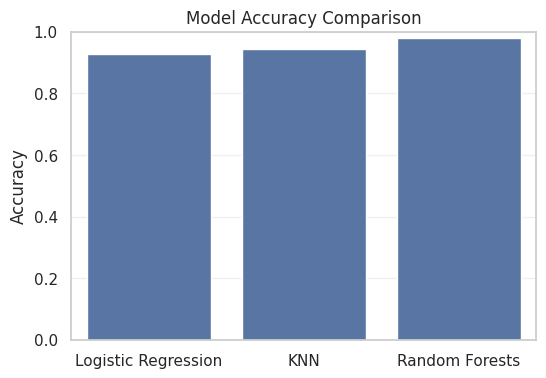


=== Linear Regression (target protein: BDNF_N) ===
R^2 : 0.9050
RMSE: 0.0386


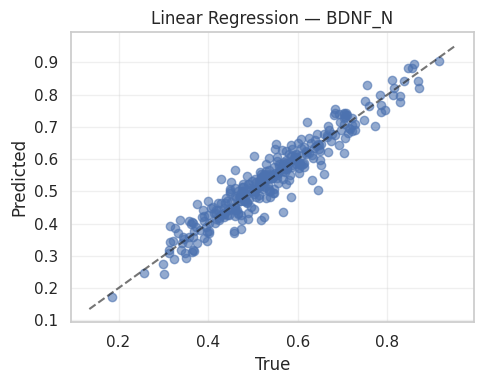

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np


reg_target = "BDNF_N"
if reg_target not in features.columns:
    reg_target = features.columns[0]

Xr = features.drop(columns=[reg_target]).copy()
yr = features[reg_target].copy()

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.3, random_state=42
)

linreg = LinearRegression()
linreg.fit(Xr_train, yr_train)
yr_pred = linreg.predict(Xr_test)

linreg_r2  = r2_score(yr_test, yr_pred)
linreg_rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))

print(f"\n=== Linear Regression (target protein: {reg_target}) ===")
print("R^2 :", f"{linreg_r2:.4f}")
print("RMSE:", f"{linreg_rmse:.4f}")

plt.figure(figsize=(5,4))
plt.scatter(yr_test, yr_pred, alpha=0.6)
plt.xlabel("True"); plt.ylabel("Predicted")
plt.title(f"Linear Regression — {reg_target}")
lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(lims, lims, 'k--', alpha=0.6)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Epoch 01 — accuracy: 0.5833
Epoch 02 — accuracy: 0.5772
Epoch 03 — accuracy: 0.8673
Epoch 04 — accuracy: 0.8920
Epoch 05 — accuracy: 0.8642
Epoch 06 — accuracy: 0.8179
Epoch 07 — accuracy: 0.7068
Epoch 08 — accuracy: 0.9198
Epoch 09 — accuracy: 0.8488
Epoch 10 — accuracy: 0.9074
Epoch 11 — accuracy: 0.9383
Epoch 12 — accuracy: 0.9383
Epoch 13 — accuracy: 0.9444
Epoch 14 — accuracy: 0.9537
Epoch 15 — accuracy: 0.9599
Epoch 16 — accuracy: 0.9630
Epoch 17 — accuracy: 0.9660
Epoch 18 — accuracy: 0.9660
Epoch 19 — accuracy: 0.9660
Epoch 20 — accuracy: 0.9660
Epoch 21 — accuracy: 0.9660
Epoch 22 — accuracy: 0.9660
Epoch 23 — accuracy: 0.9691
Epoch 24 — accuracy: 0.9691
Epoch 25 — accuracy: 0.9691
Epoch 26 — accuracy: 0.9691
Epoch 27 — accuracy: 0.9660
Epoch 28 — accuracy: 0.9660
Epoch 29 — accuracy: 0.9691
Epoch 30 — accuracy: 0.9691
Epoch 31 — accuracy: 0.9691
Epoch 32 — accuracy: 0.9722
Epoch 33 — accuracy: 0.9722
Epoch 34 — accuracy: 0.9722
Epoch 35 — accuracy: 0.9722
Epoch 36 — accuracy:

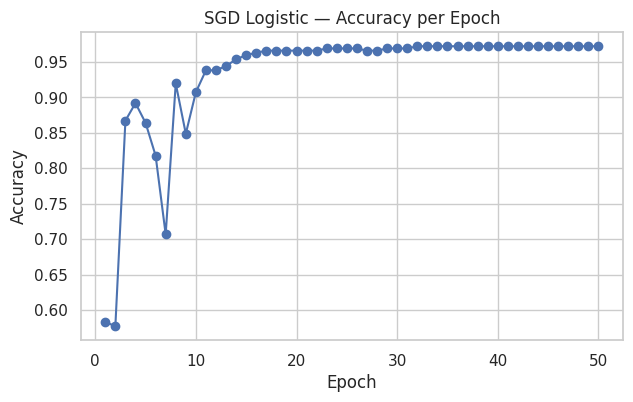

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

sgd = SGDClassifier(loss="log_loss", learning_rate="optimal", alpha=1e-4,
                    random_state=42, warm_start=True)

n_epochs = 50
epoch_acc = []

classes = np.unique(y_train)
sgd.partial_fit(x_train, y_train, classes=classes)
acc = accuracy_score(y_test, sgd.predict(x_test))
epoch_acc.append(acc)
print(f"Epoch 01 — accuracy: {acc:.4f}")

for e in range(2, n_epochs + 1):
    sgd.partial_fit(x_train, y_train)
    acc = accuracy_score(y_test, sgd.predict(x_test))
    epoch_acc.append(acc)
    print(f"Epoch {e:02d} — accuracy: {acc:.4f}")



plt.plot(range(1, n_epochs+1), epoch_acc, marker="o")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("SGD Logistic — Accuracy per Epoch")
plt.grid(True); plt.show()

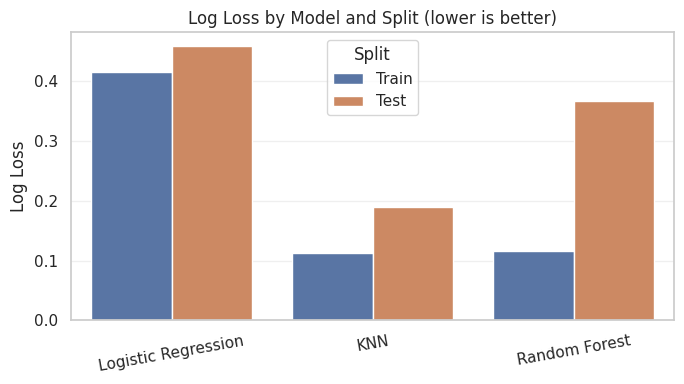

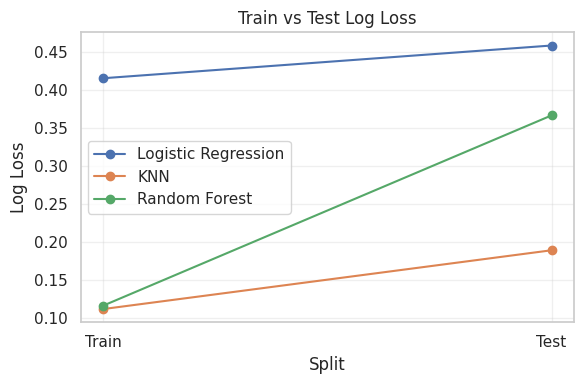

In [ ]:
from sklearn.metrics import log_loss
loss_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Logistic Regression",
              "KNN", "KNN",
              "Random Forest", "Random Forest"],
    "Split": ["Train", "Test",
              "Train", "Test",
              "Train", "Test"],
    "LogLoss": [lr_train_loss, lr_test_loss,
                knn_train_loss, knn_test_loss,
                rf_train_loss, rf_test_loss]
})

plt.figure(figsize=(7,4))
sns.barplot(data=loss_df, x="Model", y="LogLoss", hue="Split")
plt.title("Log Loss by Model and Split (lower is better)")
plt.ylabel("Log Loss")
plt.xlabel("")
plt.xticks(rotation=10)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: train vs test lines for each model (quick comparison)
plt.figure(figsize=(6,4))
for model in loss_df["Model"].unique():
    sub = loss_df[loss_df["Model"] == model].set_index("Split").loc[["Train","Test"]]
    plt.plot(["Train","Test"], sub["LogLoss"].values, marker="o", label=model)
plt.title("Train vs Test Log Loss")
plt.ylabel("Log Loss"); plt.xlabel("Split")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Epoch 01 | train loss 6.7994, val loss 8.3895 | train acc 0.6455, val acc 0.5772
Epoch 02 | train loss 2.0072, val loss 1.7724 | train acc 0.8439, val acc 0.8673
Epoch 03 | train loss 1.6377, val loss 1.5274 | train acc 0.8836, val acc 0.8920
Epoch 04 | train loss 1.7905, val loss 1.7583 | train acc 0.8704, val acc 0.8642
Epoch 05 | train loss 1.3678, val loss 1.5110 | train acc 0.8492, val acc 0.8179
Epoch 06 | train loss 2.3991, val loss 2.7054 | train acc 0.7407, val acc 0.7068
Epoch 07 | train loss 0.6045, val loss 0.6042 | train acc 0.9206, val acc 0.9198
Epoch 08 | train loss 1.0145, val loss 1.0828 | train acc 0.8519, val acc 0.8488
Epoch 09 | train loss 0.6438, val loss 0.6352 | train acc 0.9048, val acc 0.9074
Epoch 10 | train loss 0.3665, val loss 0.3950 | train acc 0.9339, val acc 0.9383
Epoch 11 | train loss 0.3504, val loss 0.3872 | train acc 0.9246, val acc 0.9383
Epoch 12 | train loss 0.2815, val loss 0.3380 | train acc 0.9339, val acc 0.9444
Epoch 13 | train loss 0.2035

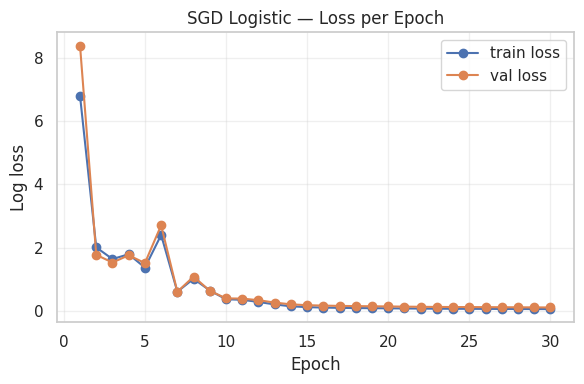

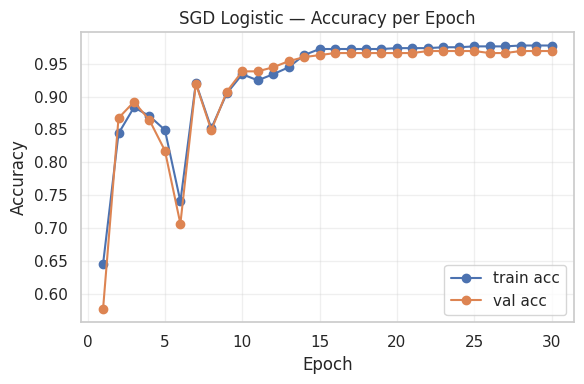

In [ ]:

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score

def _proba_from_decision(decision):
    if decision.ndim == 1:
        p1 = 1.0 / (1.0 + np.exp(-decision))
        return np.c_[1 - p1, p1]
    elif decision.shape[1] == 1:
        p1 = 1.0 / (1.0 + np.exp(-decision.ravel()))
        return np.c_[1 - p1, p1]
    else:
        z = decision - decision.max(axis=1, keepdims=True)
        e = np.exp(z)
        return e / e.sum(axis=1, keepdims=True)

sgd = SGDClassifier(
    loss="log_loss",
    learning_rate="optimal",
    alpha=1e-4,
    random_state=42,
    max_iter=1,
    tol=None,
    warm_start=True
)

classes = np.unique(y_train)
n_epochs = 30

train_losses, val_losses = [], []
train_accs, val_accs     = [], []

sgd.partial_fit(x_train, y_train, classes=classes)

for epoch in range(1, n_epochs + 1):

    sgd.partial_fit(x_train, y_train)

    train_dec = sgd.decision_function(x_train)
    train_proba = _proba_from_decision(train_dec)
    train_loss = log_loss(y_train, train_proba, labels=classes)
    train_pred = sgd.predict(x_train)
    train_acc = accuracy_score(y_train, train_pred)

    val_dec = sgd.decision_function(x_test)
    val_proba = _proba_from_decision(val_dec)
    val_loss = log_loss(y_test, val_proba, labels=classes)
    val_pred = sgd.predict(x_test)
    val_acc = accuracy_score(y_test, val_pred)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);     val_accs.append(val_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {train_loss:.4f}, val loss {val_loss:.4f} | "
          f"train acc {train_acc:.4f}, val acc {val_acc:.4f}")

epochs = np.arange(1, n_epochs + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, marker="o", label="train loss")
plt.plot(epochs, val_losses, marker="o", label="val loss")
plt.xlabel("Epoch"); plt.ylabel("Log loss"); plt.title("SGD Logistic — Loss per Epoch")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, train_accs, marker="o", label="train acc")
plt.plot(epochs, val_accs, marker="o", label="val acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("SGD Logistic — Accuracy per Epoch")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

def evaluate_classifier(name, model):
    model.fit(x_train, y_train)
    preds = model.predict(x_test)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_test, preds, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_test, preds)

    auc = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(x_test)
        y_test_bin = label_binarize(y_test, classes=range(len(np.unique(y_test))))
        auc = roc_auc_score(y_test_bin, proba, multi_class='ovr')

    print(f"\n=== {name} ===")
    print("Accuracy :", f"{acc:.4f}")
    print("Precision:", f"{prec:.4f}")
    print("Recall   :", f"{rec:.4f}")
    print("F1-score :", f"{f1:.4f}")
    if auc is not None:
        print("AUC      :", f"{auc:.4f}")
    print("Confusion Matrix:\n", cm)
    return {"name": name, "model": model, "acc": acc, "prec": prec, "rec": rec, "f1": f1, "auc": auc, "cm": cm}

sgd_base  = SGDClassifier(loss="log_loss", alpha=1e-4, learning_rate="optimal",
                          random_state=42, max_iter=1000, tol=1e-3)
sgd_model = CalibratedClassifierCV(sgd_base, method="sigmoid", cv=3)
sgd_res   = evaluate_classifier("SGD Logistic (calibrated)", sgd_model)


=== SGD Logistic (calibrated) ===
Accuracy : 0.9722
Precision: 0.9727
Recall   : 0.9722
F1-score : 0.9722
AUC      : 0.9988
Confusion Matrix:
 [[44  1  1  0  1  0  0  0]
 [ 2 47  0  0  0  0  0  0]
 [ 0  0 42  0  0  0  0  0]
 [ 0  0  0 42  0  0  0  2]
 [ 0  1  0  0 30  0  0  0]
 [ 0  0  0  0  0 33  0  0]
 [ 0  0  1  0  0  0 37  0]
 [ 0  0  0  0  0  0  0 40]]


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

log_res = {"name":"Logistic Regression","model":log_model,
           "acc":logistic_accuracy,"prec":logistic_precision,"rec":logistic_recall,
           "f1":logistic_f1,"auc":logistic_auc,"cm":logistic_cm}

knn_res = {"name":"K-Nearest Neighbors (k=7)","model":knn_model,
           "acc":knn_accuracy,"prec":knn_precision,"rec":knn_recall,
           "f1":knn_f1,"auc":knn_auc,"cm":knn_cm}

rf_res  = {"name":"Random Forests","model":rf_model,
           "acc":rf_accuracy,"prec":rf_precision,"rec":rf_recall,
           "f1":rf_f1,"auc":rf_auc,"cm":rf_cm}

all_results = [log_res, knn_res, rf_res, sgd_res]

summary = pd.DataFrame([{
    "Model": r["name"], "Accuracy": r["acc"], "Precision": r["prec"],
    "Recall": r["rec"], "F1": r["f1"], "AUC": r["auc"]
} for r in all_results])

print("\n=== Test-set Metrics Summary ===")
display(summary.sort_values("Accuracy", ascending=False).reset_index(drop=True))



=== Test-set Metrics Summary ===


,Model,Accuracy,Precision,Recall,F1,AUC
0,Random Forests,0.981481,0.984484,0.981481,0.981373,0.999631
1,SGD Logistic (calibrated),0.972222,0.972663,0.972222,0.972194,0.998768
2,K-Nearest Neighbors (k=7),0.944444,0.950029,0.944444,0.943812,0.998679
3,Logistic Regression,0.929012,0.930852,0.929012,0.929176,0.996097


In [ ]:

best_row = summary.iloc[summary["Accuracy"].idxmax()]
print(f"\n>>> Best test classifier: {best_row['Model']} (Accuracy = {best_row['Accuracy']:.4f})")



>>> Best test classifier: Random Forests (Accuracy = 0.9815)


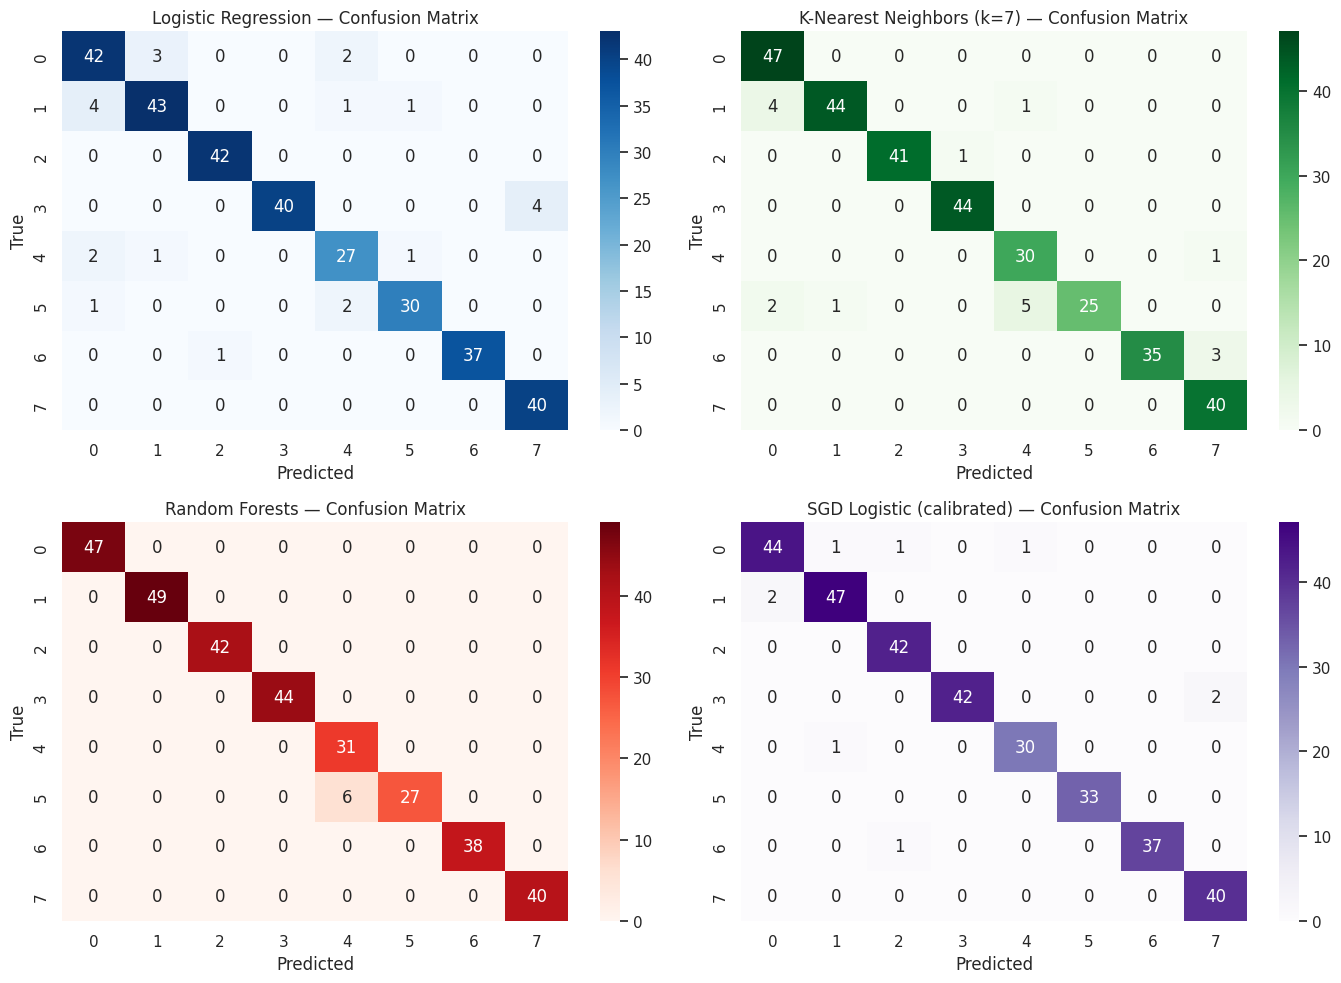

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
cmaps = ["Blues","Greens","Reds","Purples"]

for ax, res, cmap in zip(axes, all_results, cmaps):
    sns.heatmap(res["cm"], annot=True, fmt="d", cmap=cmap, ax=ax)
    ax.set_title(f"{res['name']} — Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

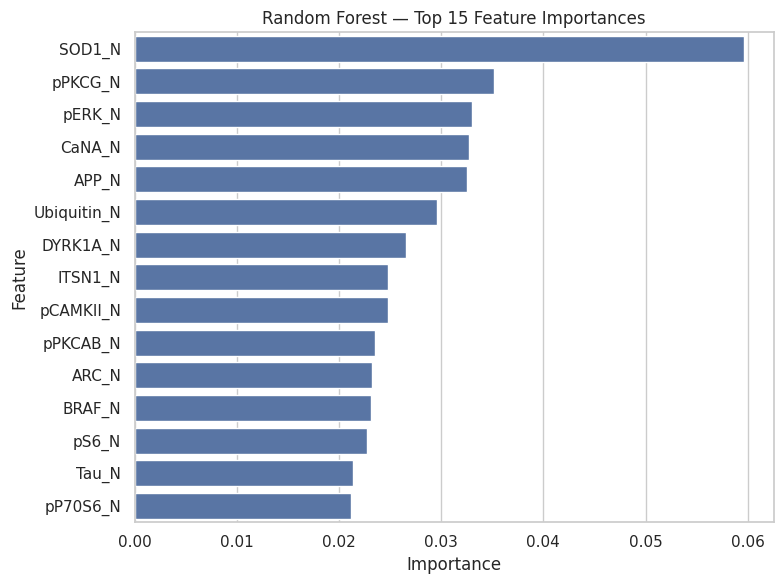

In [ ]:
if hasattr(rf_model, "feature_importances_"):
    importances = pd.Series(rf_model.feature_importances_, index=features.columns)
    topN = 15
    plt.figure(figsize=(8,6))
    sns.barplot(x=importances.nlargest(topN).values,
                y=importances.nlargest(topN).index, orient="h")
    plt.title(f"Random Forest — Top {topN} Feature Importances")
    plt.xlabel("Importance"); plt.ylabel("Feature")
    plt.tight_layout(); plt.show()

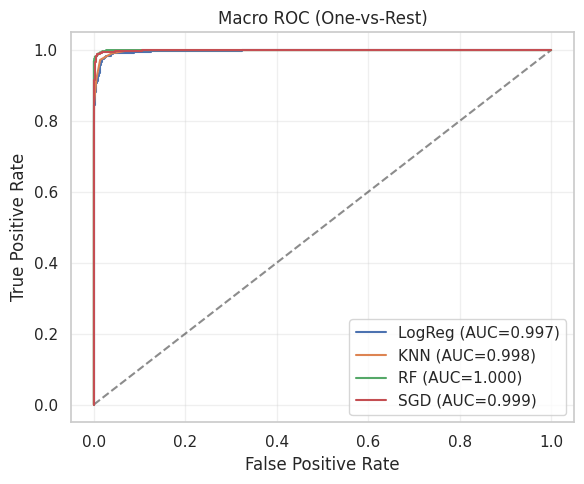

In [ ]:

def plot_macro_roc(ax, model, label):
    if not hasattr(model, "predict_proba"):
        return
    n_classes = len(np.unique(y_test))
    y_bin = label_binarize(y_test, classes=range(n_classes))
    probs = model.predict_proba(x_test)
    fpr, tpr, _ = roc_curve(y_bin.ravel(), probs.ravel())
    ax.plot(fpr, tpr, label=f"{label} (AUC={auc(fpr, tpr):.3f})")

fig, ax = plt.subplots(figsize=(6,5))
ax.plot([0,1],[0,1],"k--", alpha=0.5)
plot_macro_roc(ax, log_model, "LogReg")
plot_macro_roc(ax, knn_model, "KNN")
plot_macro_roc(ax, rf_model,  "RF")
plot_macro_roc(ax, sgd_res["model"], "SGD")
ax.set_title("Macro ROC (One-vs-Rest)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()